In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [4]:
# Set display options
pd.options.display.float_format = '{:.2f}'.format

In [6]:
# Load customers data
customers = pd.read_csv('../data/raw/customers.csv')

In [8]:
chunk_size = 1_000_000  # Process 1 million rows at a time
chunk_list = []  # Store results from each chunk
chunk_count = 0

# This reads the CSV in chunks
for chunk in pd.read_csv('../data/raw/transactions_train.csv', 
                        parse_dates=['t_dat'],
                        chunksize=chunk_size):
    
    chunk_count += 1
    print(f"Processing chunk {chunk_count} ({len(chunk):,} rows)...")
    
    # For THIS chunk, calculate customer-level stats
    chunk_agg = chunk.groupby('customer_id').agg({
        't_dat': ['min', 'max', 'count'],  # first purchase, last purchase, total purchases
        'price': ['sum', 'mean']            # total spending, average price
    })
    
    # Flatten column names
    chunk_agg.columns = ['first_purchase', 'last_purchase', 'total_purchases', 
                         'total_spending', 'avg_price']
    
    # Add this chunk's results to our list
    chunk_list.append(chunk_agg)
    
    print(f"  → Found {len(chunk_agg):,} unique customers in this chunk")

print("="*60)
print(f"Processed {chunk_count} chunks total")

Processing chunk 1 (1,000,000 rows)...
  → Found 214,936 unique customers in this chunk
Processing chunk 2 (1,000,000 rows)...
  → Found 212,129 unique customers in this chunk
Processing chunk 3 (1,000,000 rows)...
  → Found 228,136 unique customers in this chunk
Processing chunk 4 (1,000,000 rows)...
  → Found 235,993 unique customers in this chunk
Processing chunk 5 (1,000,000 rows)...
  → Found 208,446 unique customers in this chunk
Processing chunk 6 (1,000,000 rows)...
  → Found 206,351 unique customers in this chunk
Processing chunk 7 (1,000,000 rows)...
  → Found 215,187 unique customers in this chunk
Processing chunk 8 (1,000,000 rows)...
  → Found 201,411 unique customers in this chunk
Processing chunk 9 (1,000,000 rows)...
  → Found 196,573 unique customers in this chunk
Processing chunk 10 (1,000,000 rows)...
  → Found 192,533 unique customers in this chunk
Processing chunk 11 (1,000,000 rows)...
  → Found 195,621 unique customers in this chunk
Processing chunk 12 (1,000,000

In [20]:
print("Combining all chunks...")
print("(This takes a minute - we're merging data for customers who appear in multiple chunks)")

# Concatenate all chunk results
all_customers = pd.concat(chunk_list)
# Reference date for recency calculation (last date in dataset: 2020-09-22)
reference_date = pd.Timestamp('2020-09-22')

print(f"\nBefore combining: {len(all_customers):,} rows (customers appear multiple times)")

# Now group by customer_id to combine their data across chunks
customer_features = all_customers.groupby('customer_id').agg({
    'first_purchase': 'min',      # Earliest purchase date across all chunks
    'last_purchase': 'max',       # Latest purchase date across all chunks
    'total_purchases': 'sum',     # Sum purchases across all chunks
    'total_spending': 'sum',      # Sum spending across all chunks
    'avg_price': 'mean'           # Average of averages (not perfect but close enough)
})

print(f"After combining: {len(customer_features):,} unique customers")

# Calculate recency (days since last purchase)
customer_features['recency_days'] = (reference_date - customer_features['last_purchase']).dt.days

print("\n" + "="*60)
print("CUSTOMER FEATURES CREATED")
print("="*60)
print(customer_features.head(2).T)
print("\nFeature Summary:")
print(customer_features.describe())

Combining all chunks...
(This takes a minute - we're merging data for customers who appear in multiple chunks)

Before combining: 6,652,981 rows (customers appear multiple times)
After combining: 1,362,281 unique customers

CUSTOMER FEATURES CREATED
customer_id     00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657  \
first_purchase                                 2018-12-27 00:00:00                 
last_purchase                                  2020-09-05 00:00:00                 
total_purchases                                                 21                 
total_spending                                                0.65                 
avg_price                                                     0.03                 
recency_days                                                    17                 

customer_id     0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa  
first_purchase                                 2018-09-21 00:00:00            

In [22]:
# Load customer demographics
print("Merging with customer demographics to get age...")
customers = pd.read_csv('../data/raw/customers.csv')

print(f"Total customers in demographics file: {len(customers):,}")
print(f"Customers with age data: {customers['age'].notna().sum():,}")

# Merge to add age
customer_features = customer_features.merge(
    customers[['customer_id', 'age']], 
    on='customer_id', 
    how='left'
)

print(f"\nAfter merge: {len(customer_features):,} customers")
print(f"Customers with age: {customer_features['age'].notna().sum():,}")

# Check what we have now
print("\nFeatures available for clustering:")
print(customer_features.head(1).T)

print("\nMissing values:")
print(customer_features.isnull().sum())

Merging with customer demographics to get age...
Total customers in demographics file: 1,371,980
Customers with age data: 1,356,119

After merge: 1,362,281 customers
Customers with age: 1,346,520

Features available for clustering:
                                                                 0
customer_id      00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...
first_purchase                                 2018-12-27 00:00:00
last_purchase                                  2020-09-05 00:00:00
total_purchases                                                 21
total_spending                                                0.65
avg_price                                                     0.03
recency_days                                                    17
age                                                          49.00

Missing values:
customer_id            0
first_purchase         0
last_purchase          0
total_purchases        0
total_spending         0
avg_price              

In [24]:
customer_features_clean = customer_features.dropna(subset=['age'])
print(f"Customers for clustering: {len(customer_features_clean):,}")

Customers for clustering: 1,346,520


In [26]:
# Select features for clustering
# We'll use: age, total_purchases, total_spending, avg_price, recency_days
clustering_features = ['age', 'total_purchases', 'total_spending', 'avg_price', 'recency_days']

X = customer_features_clean[clustering_features].copy()

print("Features for clustering:")
print(X.describe())

# Check for any remaining issues
print("\nAny nulls left?", X.isnull().sum().sum())
print("Any infinite values?", np.isinf(X).sum().sum())

Features for clustering:
             age  total_purchases  total_spending  avg_price  recency_days
count 1346520.00       1346520.00      1346520.00 1346520.00    1346520.00
mean       36.40            23.50            0.65       0.03        233.50
std        14.31            39.41            1.20       0.01        220.38
min        16.00             1.00            0.00       0.00          0.00
25%        24.00             3.00            0.09       0.02         48.00
50%        32.00             9.00            0.25       0.03        149.00
75%        49.00            27.00            0.71       0.03        394.00
max        99.00          1895.00           57.68       0.51        733.00

Any nulls left? 0
Any infinite values? 0


In [30]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized!")
print("Shape:", X_scaled.shape)
print("\nScaled feature means (should be ~0):", X_scaled.mean(axis=0))
print("Scaled feature stds (should be ~1):", X_scaled.std(axis=0))

Features standardized!
Shape: (1346520, 5)

Scaled feature means (should be ~0): [ 5.79190585e-17  7.99975335e-18 -1.51979483e-16  1.21211038e-15
 -4.68481598e-17]
Scaled feature stds (should be ~1): [1. 1. 1. 1. 1.]


In [32]:
# Try different numbers of clusters
inertias = []
silhouette_scores = []

print("Testing different cluster counts...")
print("="*60)

for k in [3, 4, 5]:
    print(f"\nTrying k={k} clusters...")
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertia = kmeans.inertia_
    inertias.append(inertia)
    
    # Count cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    print(f"  Cluster sizes: {dict(zip(unique, counts))}")
    print(f"  Inertia: {inertia:,.0f}")

print("\n" + "="*60)
print("Inertia by k (lower = tighter clusters):")
for i, k in enumerate([3, 4, 5]):
    print(f"  k={k}: {inertias[i]:,.0f}")

Testing different cluster counts...

Trying k=3 clusters...
  Cluster sizes: {0: 75516, 1: 812951, 2: 458053}
  Inertia: 4,018,702

Trying k=4 clusters...
  Cluster sizes: {0: 357853, 1: 571903, 2: 71510, 3: 345254}
  Inertia: 3,279,350

Trying k=5 clusters...
  Cluster sizes: {0: 553848, 1: 334182, 2: 66422, 3: 69144, 4: 322924}
  Inertia: 2,746,569

Inertia by k (lower = tighter clusters):
  k=3: 4,018,702
  k=4: 3,279,350
  k=5: 2,746,569


as k=4 cluster is the most balanced analysing it further

In [37]:
# Fit final model with k=4
print("Fitting final model with k=4...")
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
# Create a proper copy to avoid the warning
customer_features_clean = customer_features_clean.copy()
customer_features_clean['cluster'] = kmeans_final.fit_predict(X_scaled)

print("Clusters assigned!")

# Analyze cluster characteristics
print("\n" + "="*60)
print("CLUSTER PROFILES")
print("="*60)

cluster_profiles = customer_features_clean.groupby('cluster')[clustering_features].mean()
print("\nAverage values by cluster:")
print(cluster_profiles)

print("\nCluster sizes:")
print(customer_features_clean['cluster'].value_counts().sort_index())

print("\nCluster size percentages:")
print((customer_features_clean['cluster'].value_counts(normalize=True).sort_index() * 100).round(1))

Fitting final model with k=4...
Clusters assigned!

CLUSTER PROFILES

Average values by cluster:
          age  total_purchases  total_spending  avg_price  recency_days
cluster                                                                
0       53.29            18.41            0.53       0.03        157.54
1       25.86            21.55            0.55       0.03        111.76
2       36.43           149.06            4.48       0.03         41.37
3       36.33             6.01            0.16       0.03        553.68

Cluster sizes:
cluster
0    357853
1    571903
2     71510
3    345254
Name: count, dtype: int64

Cluster size percentages:
cluster
0   26.60
1   42.50
2    5.30
3   25.60
Name: proportion, dtype: float64


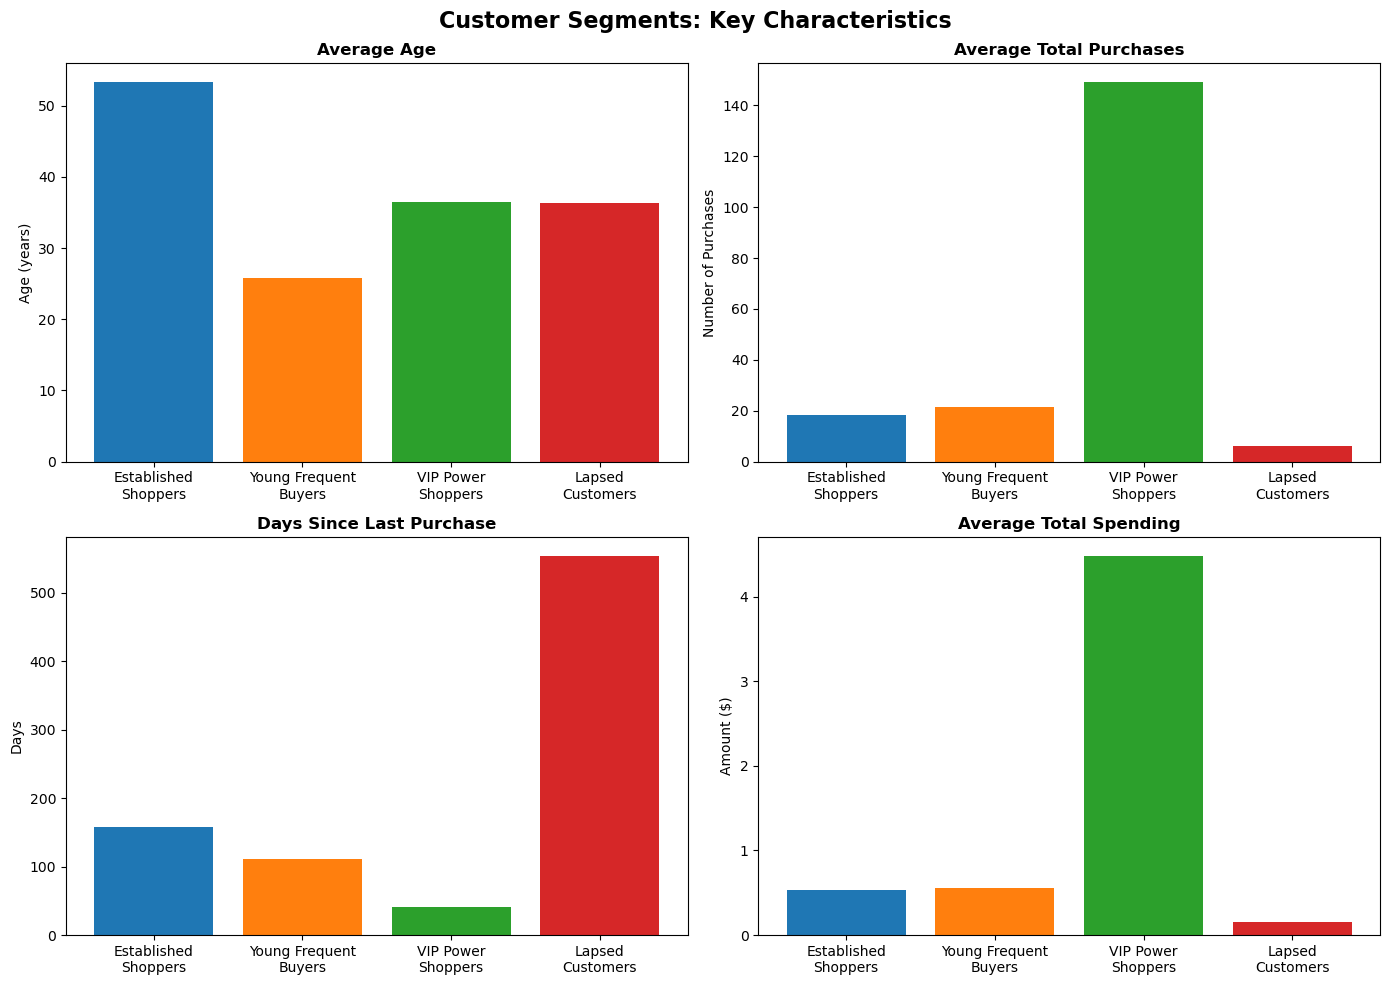

Saved: day6_segments_4charts.png


In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Segments: Key Characteristics', fontsize=16, fontweight='bold')

# Define cluster names
cluster_names = {
    0: 'Established\nShoppers',
    1: 'Young Frequent\nBuyers', 
    2: 'VIP Power\nShoppers',
    3: 'Lapsed\nCustomers'
}

# Rename clusters in our data for plotting
plot_data = cluster_profiles.copy()
plot_data.index = plot_data.index.map(cluster_names)

# 1. Age
axes[0,0].bar(plot_data.index, plot_data['age'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0,0].set_title('Average Age', fontweight='bold')
axes[0,0].set_ylabel('Age (years)')

# 2. Total Purchases
axes[0,1].bar(plot_data.index, plot_data['total_purchases'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0,1].set_title('Average Total Purchases', fontweight='bold')
axes[0,1].set_ylabel('Number of Purchases')

# 3. Recency
axes[1,0].bar(plot_data.index, plot_data['recency_days'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1,0].set_title('Days Since Last Purchase', fontweight='bold')
axes[1,0].set_ylabel('Days')

# 4. Total Spending
axes[1,1].bar(plot_data.index, plot_data['total_spending'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1,1].set_title('Average Total Spending', fontweight='bold')
axes[1,1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.savefig('../visualizations/day6_segments_4charts.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: day6_segments_4charts.png")

In [47]:
# Calculate total revenue contribution by segment
cluster_profiles['total_revenue'] = cluster_profiles['size'] * cluster_profiles['total_spending']
cluster_profiles['revenue_pct'] = (cluster_profiles['total_revenue'] / cluster_profiles['total_revenue'].sum() * 100).round(1)

print("Revenue Contribution by Segment:")
print(cluster_profiles[['size', 'pct', 'total_revenue', 'revenue_pct']])

Revenue Contribution by Segment:
           size   pct  total_revenue  revenue_pct
cluster                                          
0        357853 26.60      189439.24        21.50
1        571903 42.50      317189.62        36.00
2         71510  5.30      320477.45        36.40
3        345254 25.60       53735.16         6.10


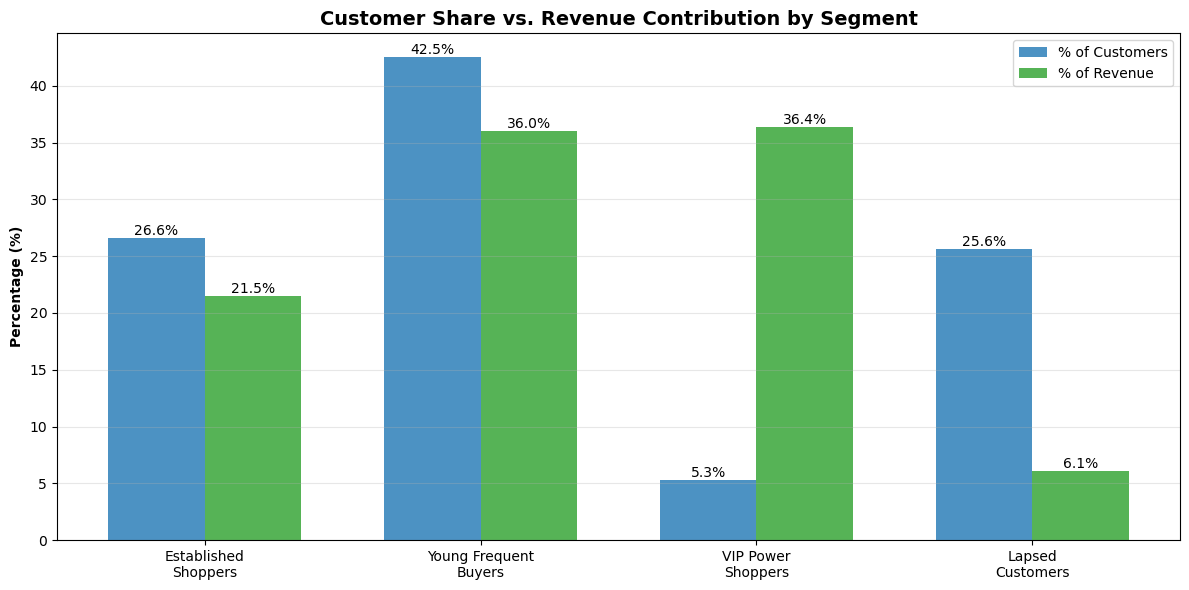

Saved: day6_customer_vs_revenue.png


In [49]:
# Create a comparison chart: Customer Share vs Revenue Share
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(cluster_names))
width = 0.35

# Prepare data
segment_labels = [cluster_names[i] for i in range(4)]
customer_pct = cluster_profiles['pct'].values
revenue_pct = cluster_profiles['revenue_pct'].values

# Create bars
bars1 = ax.bar(x - width/2, customer_pct, width, label='% of Customers', color='#1f77b4', alpha=0.8)
bars2 = ax.bar(x + width/2, revenue_pct, width, label='% of Revenue', color='#2ca02c', alpha=0.8)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Percentage (%)', fontweight='bold')
ax.set_title('Customer Share vs. Revenue Contribution by Segment', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(segment_labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/day6_customer_vs_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: day6_customer_vs_revenue.png")

H&M CUSTOMER SEGMENTATION ANALYSIS
==================================

Using K-means clustering on 1.35M customers, I identified 4 distinct segments:

SEGMENT 1: Young Frequent Buyers (42.5% of customers, 572k)
- Average age: 26 years
- Purchase behavior: 22 purchases, last bought 112 days ago
- Revenue contribution: 36.0% (proportional to size)

SEGMENT 2: Established Shoppers (26.6% of customers, 358k)
- Average age: 53 years
- Purchase behavior: 18 purchases, last bought 157 days ago
- Revenue contribution: 21.5% (slightly under-represented)

SEGMENT 3: VIP Power Shoppers (5.3% of customers, 72k)
- Average age: 36 years
- Purchase behavior: 149 purchases, last bought 41 days ago
- Revenue contribution: 36.4% (7x their customer share!)

SEGMENT 4: Lapsed Customers (25.6% of customers, 345k)
- Average age: 36 years
- Purchase behavior: 6 purchases, last bought 554 days ago
- Revenue contribution: 6.1% (4x lower than customer share)

KEY INSIGHTS:
- 5% of customers (VIPs) drive over one-third of total revenue
- VIP segment has 7x higher revenue contribution than their customer share
- Lapsed segment represents 26% of customers but only 6% of revenue
- Young Frequent Buyers are the largest segment and contribute proportionally